Greyson Roy \
9\20\2026 \
Lab 4 - Oscillator Simulation

In [98]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

Part A - Collisions with Restitution

1. A class with the requested function is below

In [99]:
class Particle_1d:

    def __init__(self, name, m, u):
        self.mass = m
        self.velo = u
        self.name = name

    def update(self, **kwargs):
        for key, value in kwargs.items():
            if hasattr(self, key):
                setattr(self, key, value)
            else:
                raise AttributeError(f"{type(self).__name__} object has no name attribute")

    def collide_1d(self, body_2, e):
        m1, u1 = self.mass, self.velo
        m2, u2 = body_2.mass, body_2.velo
        m_total = m1 + m2
        v_cm = (m1*u1 + m2*u2) / m_total
        v1 = v_cm - e * (m2 / m_total) * (u1 - u2)
        v2 = v_cm + e * (m1 / m_total) * (u1 - u2)
        self.update(velo = v1)
        body_2.update(velo = v2)

In [100]:
def p_total(body_1: Particle_1d, body_2: Particle_1d):
    m1, u1 = body_1.mass, body_1.velo
    m2, u2 = body_2.mass, body_2.velo
    return m1*u1 + m2*u2

def ke_total(body_1: Particle_1d, body_2: Particle_1d):
    m1, u1 = body_1.mass, body_1.velo
    m2, u2 = body_2.mass, body_2.velo
    return 0.5*m1*u1**2 + 0.5*m2*u2**2

2. The 3 limiting cases for $e=1$ are below

In [101]:
p1 = Particle_1d("p1", 1, 1)
p2 = Particle_1d("p2", 1, 0)

print('Mass p1 = Mass p2, p2 stationary')
print(f'Before the collision, the velocity of p1 is {p1.velo}')
print(f'Before the collision, the velocity of p2 is {p2.velo}')

p1.collide_1d(p2, 1)

print(f'After the collision, the velocity of p1 is {p1.velo}')
print(f'After the collision, the velocity of p2 is {p2.velo}\n')

p1 = Particle_1d("p1", 0.1, 1)
p2 = Particle_1d("p2", 100, 0)

print('Mass p1 << Mass p2, p2 stationary')
print(f'Before the collision, the velocity of p1 is {p1.velo}')
print(f'Before the collision, the velocity of p2 is {p2.velo}')

p1.collide_1d(p2, 1)

print(f'After the collision, the velocity of p1 is {p1.velo}')
print(f'After the collision, the velocity of p2 is {p2.velo}\n')

p1 = Particle_1d("p1", 100, 1)
p2 = Particle_1d("p2", 0.1, 0)

print('Mass p1 >> Mass p2, p2 stationary')
print(f'Before the collision, the velocity of p1 is {p1.velo}')
print(f'Before the collision, the velocity of p2 is {p2.velo}')

p1.collide_1d(p2, 1)

print(f'After the collision, the velocity of p1 is {p1.velo}')
print(f'After the collision, the velocity of p2 is {p2.velo}\n')

Mass p1 = Mass p2, p2 stationary
Before the collision, the velocity of p1 is 1
Before the collision, the velocity of p2 is 0
After the collision, the velocity of p1 is 0.0
After the collision, the velocity of p2 is 1.0

Mass p1 << Mass p2, p2 stationary
Before the collision, the velocity of p1 is 1
Before the collision, the velocity of p2 is 0
After the collision, the velocity of p1 is -0.9980019980019981
After the collision, the velocity of p2 is 0.0019980019980019984

Mass p1 >> Mass p2, p2 stationary
Before the collision, the velocity of p1 is 1
Before the collision, the velocity of p2 is 0
After the collision, the velocity of p1 is 0.9980019980019981
After the collision, the velocity of p2 is 1.998001998001998



3. The conservation table requested is below

|          | Pre-Collsion | Elastic (e=1) | Mixed (e=0.5) | Inelastic (e=0) |
|----------|--------------|---------------|---------------|-----------------|
| Momentum | 8.00         | 8.00          | 8.00          | 8.00            |
| KE       | 16.0         | 16.0          | 8.80          | 6.40            |

In [102]:
p1 = Particle_1d('p1', 2, 4)
p2 = Particle_1d('p2', 3, 0)

print(f'e=1:\n pre\n p={p_total(p1, p2)}\n ke={ke_total(p1, p2)}')
p1.collide_1d(p2, 1)
print(f'post\n p={p_total(p1, p2)}\n ke={ke_total(p1, p2)}\n')

p1 = Particle_1d('p1', 2, 4)
p2 = Particle_1d('p2', 3, 0)

print(f'e=0.5:\n pre\n p={p_total(p1, p2)}\n ke={ke_total(p1, p2)}')
p1.collide_1d(p2, 0.5)
print(f'post\n p={p_total(p1, p2)}\n ke={ke_total(p1, p2)}\n')

p1 = Particle_1d('p1', 2, 4)
p2 = Particle_1d('p2', 3, 0)

print(f'e=0:\n pre\n p={p_total(p1, p2)}\n ke={ke_total(p1, p2)}')
p1.collide_1d(p2, 0)
print(f'post\n p={p_total(p1, p2)}\n ke={ke_total(p1, p2)}\n')

e=1:
 pre
 p=8
 ke=16.0
post
 p=8.000000000000002
 ke=16.000000000000004

e=0.5:
 pre
 p=8
 ke=16.0
post
 p=8.000000000000002
 ke=8.800000000000002

e=0:
 pre
 p=8
 ke=16.0
post
 p=8.0
 ke=6.400000000000001



4. For each case, momentum is conserved, but kinetic energy differs across them. The missing kinetic energy would be converted to thermal, acoustic, or radiant energy in the real world.

Part B - 2D Collisions in a Box

1. A class with the 2d_collide function is below

In [103]:
class Body_2d:

    def __init__(self, name, r, m, u: np.ndarray, pos):
        self.name = name
        self.radius = r
        self.mass = m
        self.velo = u
        self.pos = pos

    def update(self, **kwargs):
        for key, value in kwargs.items():
            if hasattr(self, key):
                setattr(self, key, value)
            else:
                raise AttributeError(f"{type(self).__name__} object has no name attribute")

    def collide_1d(self, other_body, normal, e):

        m1, u1, pos1, rad1 = self.mass, self.velo.copy(), self.pos, self.radius
        m2, u2, pos2, rad2 = other_body.mass, other_body.velo.copy(), other_body.pos, other_body.radius

        v1 = np.dot(u1, normal)
        v2 = np.dot(u2, normal)

        m_total = m1 + m2
        v_cm = (m1*v1 + m2*v2) / m_total

        v1_new = v_cm - e * (m2 / m_total) * (v1 - v2)
        v2_new = v_cm + e * (m1 / m_total) * (v1 - v2)

        overlap =  rad1+rad2 - np.linalg.norm(pos1 - pos2)
        
        self.update(velo = u1 + (v1_new - v1)*normal, pos = pos1 + 0.5*overlap*normal)
        other_body.update(velo = u2 + (v2_new - v2)*normal, pos = pos2 - 0.5*overlap*normal)

    def collide_2d(self, other_body, e):

        u1, pos1 = self.velo, self.pos
        u2, pos2 = other_body.velo, other_body.pos

        dist = pos1 - pos2

        if np.linalg.norm(dist) == 0:
            return

        normal = dist/np.linalg.norm(dist)

        if np.dot(u1-u2, normal) < 0:
            self.collide_1d(other_body, normal, e)

2. Wall bouncing is included in the function below
3. The function below is written as requested

In [104]:
def two_body_box(body_1: Body_2d, body_2: Body_2d, e, box_dim: np.ndarray, dt, duration):

    mass_1, radius_1 = body_1.mass, body_1.radius
    mass_2, radius_2 = body_2.mass, body_2.radius

    if box_dim.shape != (2,):
        raise ValueError("box_dim must have shape (2,)")

    t = 0

    tot_mom = mass_1 * body_1.velo + mass_2 * body_2.velo
    tot_ke = 0.5*mass_1 * np.linalg.norm(body_1.velo)**2 + 0.5*mass_2 * np.linalg.norm(body_2.velo)**2

    t_list = [t]
    body1_pos = [body_1.pos.copy()]
    body2_pos = [body_2.pos.copy()]

    mom_list = [tot_mom.copy()]
    ke_list = [tot_ke]

    while t < duration:

        dist = np.linalg.norm(body_1.pos - body_2.pos)

        if dist <= radius_1 + radius_2:
            body_1.collide_2d(body_2, e)

        if body_1.pos[0] + radius_1 >= box_dim[0]:
            v_new = np.array([-e*body_1.velo[0], body_1.velo[1]])
            body_1.update(velo = v_new)
            body_1.update(pos = np.array([box_dim[0]-radius_1, body_1.pos[1]]))
        elif body_1.pos[0] - radius_1 <= 0:
            v_new = np.array([-e*body_1.velo[0], body_1.velo[1]])
            body_1.update(velo = v_new)
            body_1.update(pos = np.array([radius_1, body_1.pos[1]]))

        if body_1.pos[1] + radius_1 >= box_dim[1]:
            v_new = np.array([body_1.velo[0], -e*body_1.velo[1]])
            body_1.update(velo = v_new)
            body_1.update(pos = np.array([body_1.pos[0], box_dim[1]-radius_1]))
        elif body_1.pos[1] - radius_1 <= 0:
            v_new = np.array([body_1.velo[0], -e*body_1.velo[1]])
            body_1.update(velo = v_new)
            body_1.update(pos = np.array([body_1.pos[0], radius_1]))

        if body_2.pos[0] + radius_2 >= box_dim[0]:
            v_new = np.array([-e*body_2.velo[0], body_2.velo[1]])
            body_2.update(velo = v_new)
            body_2.update(pos = np.array([box_dim[0]-radius_2, body_2.pos[1]]))
        elif body_2.pos[0] - radius_2 <= 0:
            v_new = np.array([-e*body_2.velo[0], body_2.velo[1]])
            body_2.update(velo = v_new)
            body_2.update(pos = np.array([radius_2, body_2.pos[1]]))

        if body_2.pos[1] + radius_2 >= box_dim[1]:
            v_new = np.array([body_2.velo[0], -e*body_2.velo[1]])
            body_2.update(velo = v_new)
            body_2.update(pos = np.array([body_2.pos[0], box_dim[1]-radius_2]))
        elif body_2.pos[1] - radius_2 <= 0:
            v_new = np.array([body_2.velo[0], -e*body_2.velo[1]])
            body_2.update(velo = v_new)
            body_2.update(pos = np.array([body_2.pos[0], radius_2]))

        body_1.update(pos = body_1.pos + dt*body_1.velo)
        body_2.update(pos = body_2.pos + dt*body_2.velo)       

        t += dt

        t_list.append(t)

        tot_mom = mass_1 * body_1.velo + mass_2 * body_2.velo
        tot_ke = 0.5*mass_1 * np.linalg.norm(body_1.velo)**2 + 0.5*mass_2 * np.linalg.norm(body_2.velo)**2

        body1_pos.append(body_1.pos.copy())
        body2_pos.append(body_2.pos.copy())

        mom_list.append(tot_mom.copy())
        ke_list.append(tot_ke)
        
    return t_list, body1_pos, body2_pos, mom_list, ke_list

4. The run below is as requested and the plots below are as requested

[np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.5), np.float64(1.

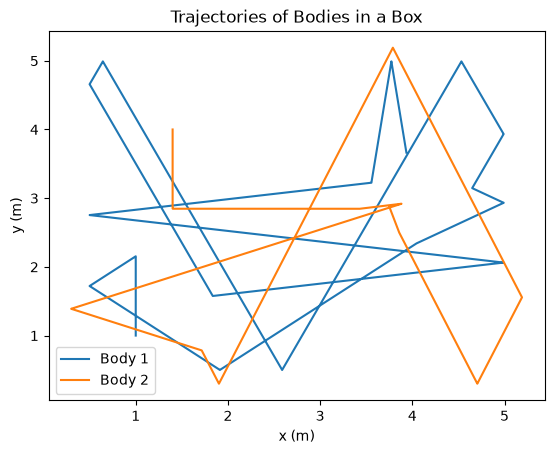

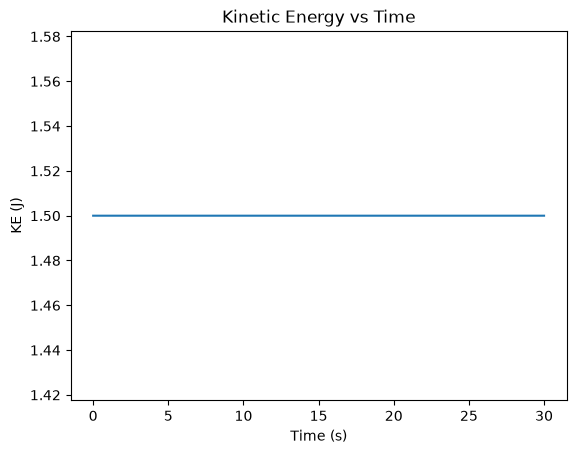

3.0


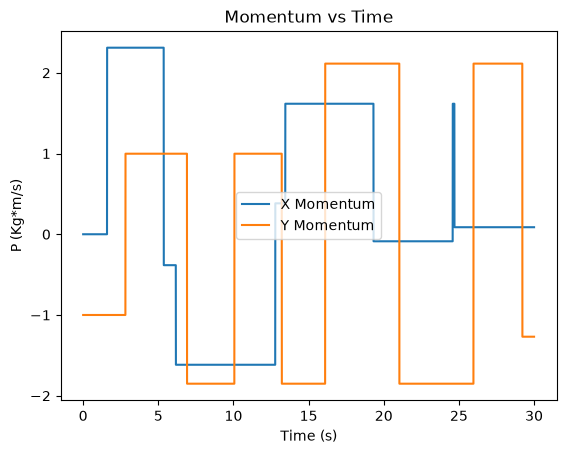

In [105]:
b1 = Body_2d('b1', 0.5, 1., np.array([0., 1.]), np.array([1., 1.]))
b2 = Body_2d('b2', 0.3, 2., np.array([0., -1.]), np.array([1.4, 4.]))

t, b1_history, b2_history, mom, ke = two_body_box(b1, b2, 1., np.array([5.49, 5.49]), 0.001, 30)

t = np.array(t)
b1_history = np.array(b1_history)
b2_history = np.array(b2_history)
mom = np.array(mom)

print(ke)

plt.plot(b1_history[:, 0], b1_history[:, 1], label='Body 1')
plt.plot(b2_history[:, 0], b2_history[:, 1], label='Body 2')
plt.legend()
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trajectories of Bodies in a Box')
plt.show()
plt.plot(t, ke)
plt.title('Kinetic Energy vs Time')
plt.xlabel('Time (s)')
plt.ylabel('KE (J)')
plt.show()
plt.plot(t, mom[:, 0], label='X Momentum')
plt.plot(t, mom[:, 1], label='Y Momentum')
plt.xlabel('Time (s)')
plt.ylabel('P (Kg*m/s)')
plt.title('Momentum vs Time')
plt.legend()
print(np.linalg.norm(np.array([0,1]))+2*np.linalg.norm(np.array([0,-1])))

5. With elastic collisions and elastic walls, the kinetic energy should stay constant throughout the whole run, which is what we see. The total momentum, however, should change when a ball hits a wall as hitting a wall negates that respective component of the momentum. This makes sense as a wall represents a body with infinite mass and acts as the limit of what we saw in the high stationary mass, low moving mass case. Since we aren't considering the momentum of the box, the total momentum changes in collisions with it.

Part C - Inelastic Collisions & Energy Accounting

1. The simulation already takes e as in input
2. The sweep is performed below with the required plots
3. The first collision ke loss is reported below

The ratio of energy after the first collision to initial kinetic energy is 1.0000 for e=1
The ratio of energy after the first collision to initial kinetic energy is 0.9091 for e=0.9
The ratio of energy after the first collision to initial kinetic energy is 0.7560 for e=0.7
The ratio of energy after the first collision to initial kinetic energy is 0.6411 for e=0.5


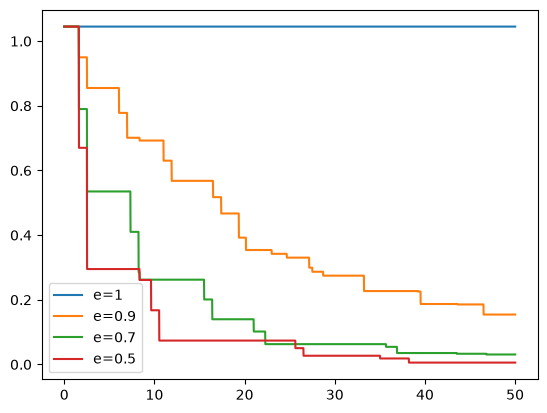

In [106]:
for e in [1, 0.9, 0.7, 0.5]:
    body_1 = Body_2d('b1', 0.5, 1, np.array([0,1]), np.array([1, 2]))
    body_2 = Body_2d('b1', 0.5, 1, np.array([0.3,-1]), np.array([2, 2.1]))
    t, pos1, pos2, p, KE = two_body_box(body_1, body_2, e, np.array([5, 5]), 0.01, 50)
    plt.plot(t, KE, label=f'e={e}')
    ratio = 1
    print(f'The ratio of energy after the first collision to initial kinetic energy is {KE[200]/KE[0]:.4f} for e={e}')
plt.legend()

4. The center mass test is below. It is a powerful test as it shows that momentum is conserved in the collision.

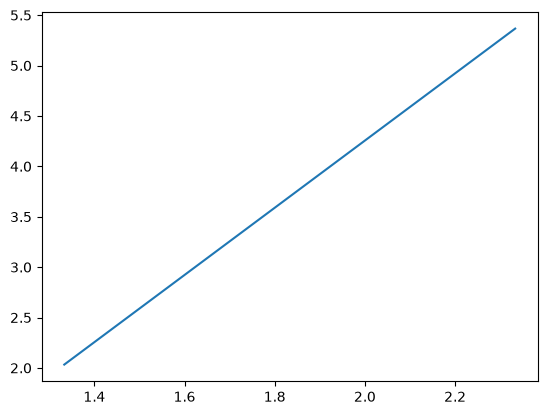

In [107]:
body_1 = Body_2d('b1', 0.5, 2, np.array([0,1]), np.array([1, 2]))
body_2 = Body_2d('b1', 0.5, 1, np.array([0.3,-1]), np.array([2, 2.1]))
dt = 0.01
t = 0
t_list = [0]
cm = [(body_1.mass*body_1.pos+body_2.mass*body_2.pos)/(body_1.mass+body_2.mass)]

while t < 10:
    m1, pos1, rad1, velo1 = body_1.mass, body_1.pos, body_1.radius, body_1.velo
    m2, pos2, rad2, velo2 = body_2.mass, body_2.pos, body_2.radius, body_2.velo
    body_1.update(pos = pos1 + dt*velo1)
    body_2.update(pos = pos2 + dt*velo2)
    dist = np.linalg.norm(pos1-pos2)
    if dist <= rad1 + rad2:
        body_1.collide_2d(body_2, e)
    t += dt
    t_list.append(t)
    cm.append((m1*pos1+m2*pos2)/(m1+m2))

cm = np.array(cm)
plt.plot(cm[:,0], cm[:,1])

5. For $e<1$ kinetic energy does not increase at any timestep, as we'd expect. If it did, then it would mean the could doesn't conserve energy as it should. While we don't have an exact solution for energy, "KE never increases" is still a valid test as if it fails, we know for sure that something is wrong, whereas it it passes, we know that at the very least the code doesn't have that one error.

Bonus - Gas in a Box

1. The generalized function is below
2. The function below is consistent with the instructions

In [108]:
def n_body_box(n, r, m, speed, e, side_length: np.ndarray, dt, duration, KE_Tracking=True, P_Tracking=True):

    theta = rng.uniform(low=0, high=2*np.pi, size=n)
    velos = [speed*np.array([np.cos(deg), np.sin(deg)]) for deg in theta]
    n_pos0 = [rng.uniform(low=r, high=side_length-r, size=2) for i in range(n)]

    bodies = [Body_2d(f'body_{i}', r, m, velos[i], n_pos0[i]) for i in range(n)]

    t = 0

    t_list = [t]

    if KE_Tracking:
        KE_list = []
        KE = 0.
        for body in bodies:
            KE += 0.5*m*np.dot(body.velo, body.velo)
        KE_list.append(KE)

    if P_Tracking:
        P_list = []
        P = np.array([0.,0.])
        for body in bodies:
            P = P + m*body.velo
        P_list.append(P.copy())

    while t < duration:

        for body in bodies:
            body.update(pos = body.pos + dt*body.velo)    

        for i in range(n):
            for j in range(i+1, n):

                body = bodies[i]
                other_body = bodies[j]

                dist = np.linalg.norm(body.pos - other_body.pos)

                if dist <= 2*r:
                    body.collide_2d(other_body, e)

        for body in bodies:

            if body.pos[0] + r >= side_length:
                v_new = np.array([-e*body.velo[0], body.velo[1]])
                body.update(velo = v_new)
                body.update(pos = np.array([side_length-r, body.pos[1]]))

            if body.pos[0] - r <= 0:
                v_new = np.array([-e*body.velo[0], body.velo[1]])
                body.update(velo = v_new)
                body.update(pos = np.array([r, body.pos[1]]))      

            if body.pos[1] + r >= side_length:
                v_new = np.array([body.velo[0], -e*body.velo[1]])
                body.update(velo = v_new)
                body.update(pos = np.array([body.pos[0], side_length-r]))

            if body.pos[1] - r <= 0:
                v_new = np.array([body.velo[0], -e*body.velo[1]])
                body.update(velo = v_new)
                body.update(pos = np.array([body.pos[0], r])) 

        t += dt

        t_list.append(t)

        if KE_Tracking:
            KE = 0.
            for body in bodies:
                KE += 0.5*m*np.dot(body.velo, body.velo)
            KE_list.append(KE)

        if P_Tracking:
            P = np.array([0.,0.])
            for body in bodies:
                P = P + m*body.velo
            P_list.append(P.copy())

    velos_t = [np.linalg.norm(body.velo) for body in bodies]

    if KE_Tracking and P_Tracking:
        return t_list, velos_t, KE_list, P_list

    elif KE_Tracking:
        return t_list, velos_t, KE_list

    elif P_Tracking:
        return t_list, velos_t, P_list

    else:
        return velos_t
    

3. The histogram is below as requested

(array([ 21.,  43.,  62.,  81., 104.,  96.,  88.,  77.,  54.,  49.,  30.,
         25.,  12.,   6.,   2.]),
 array([0.02305047, 0.17094528, 0.31884009, 0.4667349 , 0.61462971,
        0.76252452, 0.91041933, 1.05831415, 1.20620896, 1.35410377,
        1.50199858, 1.64989339, 1.7977882 , 1.94568302, 2.09357783,
        2.24147264]),
 <BarContainer object of 15 artists>)

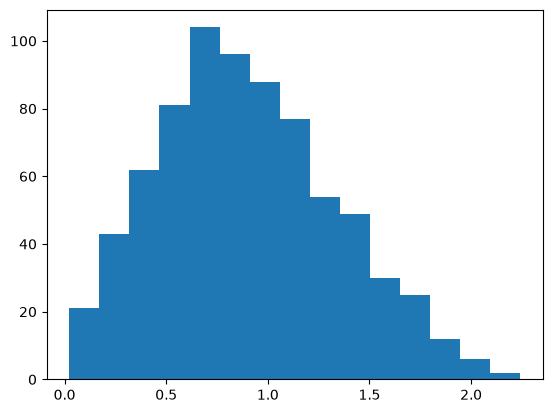

In [109]:
data = []
for i in range(25):
    data.extend(n_body_box(30, 0.5, 1, 1, 1, 50, 0.15, 150, KE_Tracking=False, P_Tracking=False))
plt.hist(data, 15)

4. From the plots below we can see that KE is conserved for the $e=1$ case, but momentum is not, as the walls of the box is not included in the calculation of the momentum.

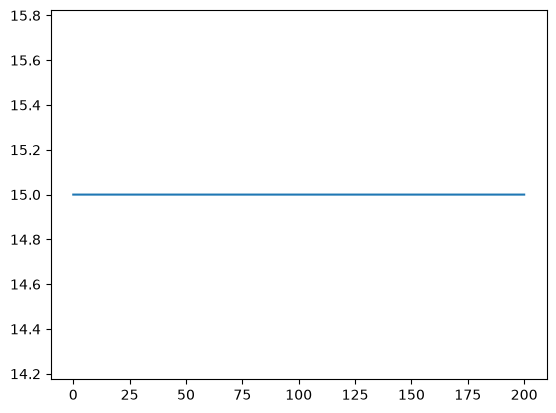

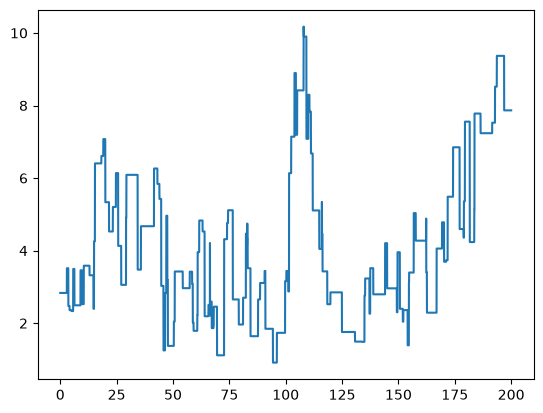

In [110]:
time, speed, energy, momentum = n_body_box(30, 0.5, 1., 1., 1., 50, 0.05, 200)

momentum = np.array(momentum)

plt.plot(time, energy)
plt.show()
norm_mom = [np.linalg.norm(mom) for mom in momentum]
plt.plot(time, norm_mom)

5. A single starting speed spreads into a distribution as the speed of each of the particles changes in every collision, and over a long enough run time, the speeds of the particles spread according to how likely it is for them to attain a certain value for speed. This is the same principle as temperature in statistical mechanics. Temperature is a measure of the average kinetic energy of particles in a medium, i.e., the average speed, however the speed of the individual particles are spread around the average in a statistical distribution.